# Preprocessing
El objetivo de este notebook es probar distintas configuraciones del pipeline de preprocesamiento y determinar cuál funciona mejor para cada modelo.

Vamos a probar en XGBoost y en regresion lineal. Vamos a utilizar el que mejor funcione para cada uno.

La que mejor funcione en regresión lineal también va a ser usada para redes neuronales

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath(".."))

from sklearn.linear_model import Ridge
from sklearn import set_config

from src.models.base_models import get_base_xgboost
from src.constants import COLS, DevSetType
from src.plots import plot_cv_results
from src.utils import get_dev_set
from preprocessing_configs_draft import (
    evaluate_pipeline_configs,
    get_xgboost_exploratory_configs,
    get_xgboost_final_configs,
    get_ridge_configs
)

set_config(transform_output="pandas")

El archivo `preprocessing_configs.py` contiene todas las configuraciones que vamos a probar.

# 1. XGBoost
Definimos distintas configuraciones a probar

En general van a ser más sencillas que las utilizadas para modelos lineales ya que no necesitan estandarización, y ni siquiera es estrictamente necesario imputar.

## 1.1 Análisis de cada transformación
Primero aplicamos una por una cada transformación para ver qué efecto tienen sobre la performance.

In [2]:
df_normal = get_dev_set(DevSetType.NORMAL)
X_normal = df_normal.drop(columns=[COLS.TARGET])
y_normal = df_normal[COLS.TARGET]

df_outliers = get_dev_set(DevSetType.OUTLIERS)
X_outliers = df_outliers.drop(columns=[COLS.TARGET])
y_outliers = df_outliers[COLS.TARGET]

### 1.1.1 Dataset Normal

In [3]:
xgb_results = evaluate_pipeline_configs(
    model_factory=lambda fp: get_base_xgboost(fp),
    pipeline_configs=get_xgboost_exploratory_configs(),
    X=X_normal,
    y=y_normal,
)

Evaluando Configuraciones: 100%|██████████| 11/11 [01:25<00:00,  7.79s/it]


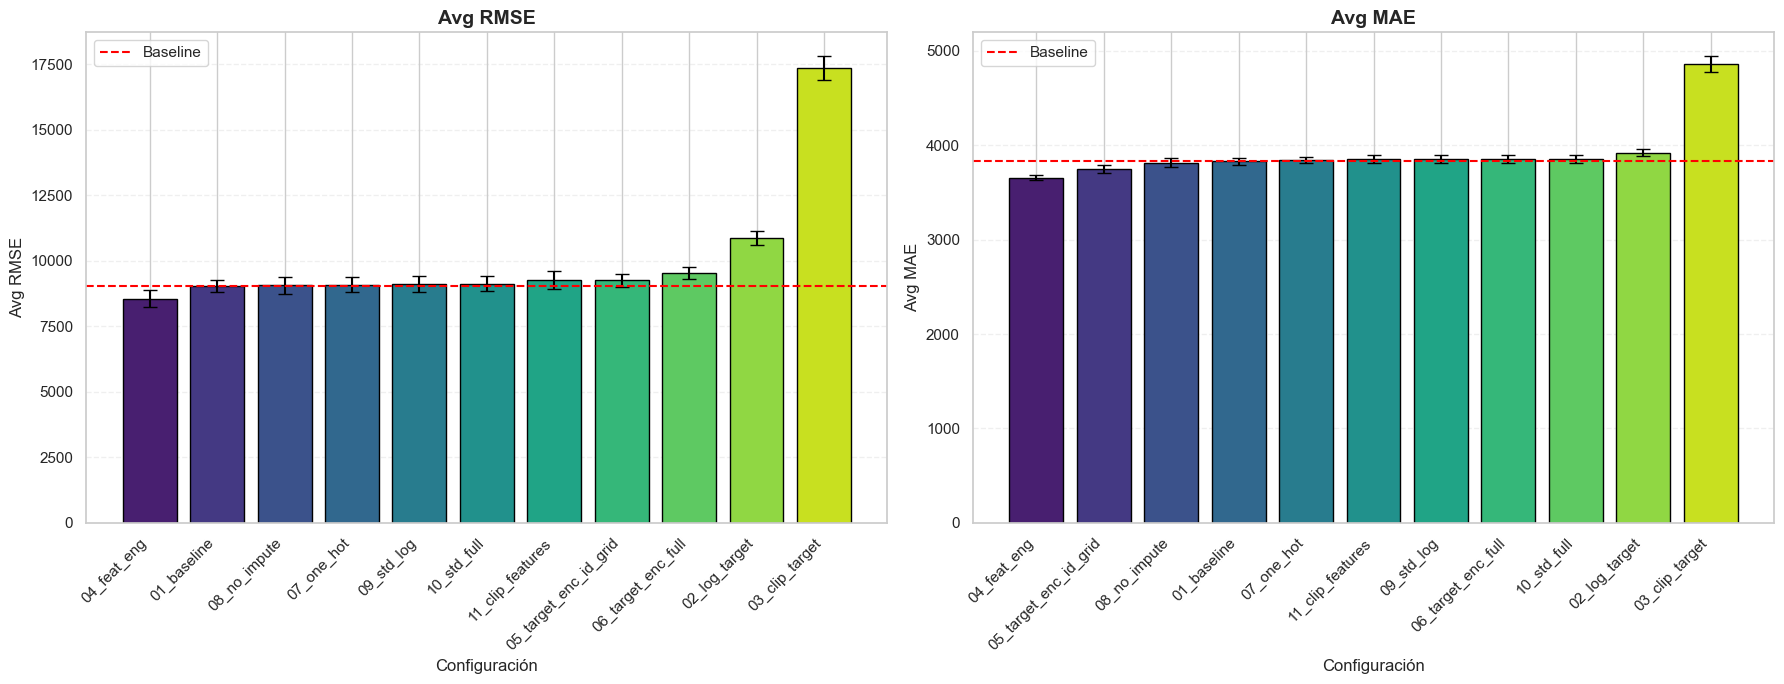

In [4]:
plot_cv_results(xgb_results, baseline_name="01_baseline", vertical_layout=False)

Con respecto al baseline, las transformaciones no parecen aportar mucho al problema. La única que tiene cierto impacto es `04_feat_eng`, que es la que agrega columnas de feature engineering.

Vamos a probar combinando algunas transformaciones a ver si tienen algun efecto.

In [5]:
xgb_results_final = evaluate_pipeline_configs(
    model_factory=lambda fp: get_base_xgboost(fp),
    pipeline_configs=get_xgboost_final_configs(),
    X=X_normal,
    y=y_normal,
)

Evaluando Configuraciones: 100%|██████████| 4/4 [00:29<00:00,  7.38s/it]


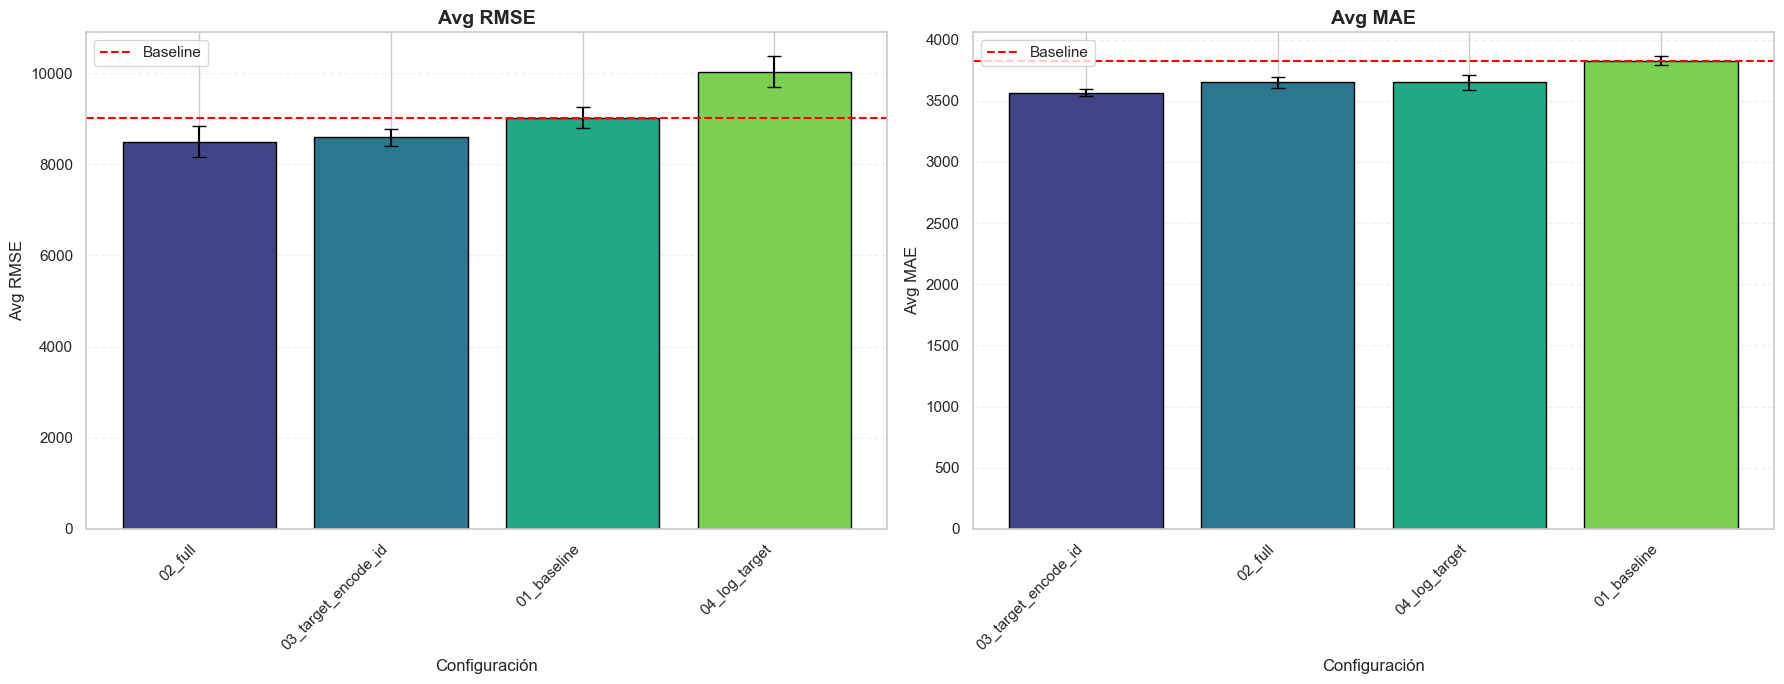

In [6]:
plot_cv_results(xgb_results_final, baseline_name="01_baseline", vertical_layout=False)

La transformación `02_full` (que lo único que hace es feature engineering, imputar y encodear) parece ser la que mejor funciona. Vamos a utilizar esta configuración para los modelos basados en árboles.

### 1.1.2 Dataset Outliers

In [7]:
xgb_results_outliers = evaluate_pipeline_configs(
    model_factory=lambda fp: get_base_xgboost(fp),
    pipeline_configs=get_xgboost_exploratory_configs(),
    X=X_outliers,
    y=y_outliers,
)

Evaluando Configuraciones: 100%|██████████| 11/11 [00:04<00:00,  2.36it/s]


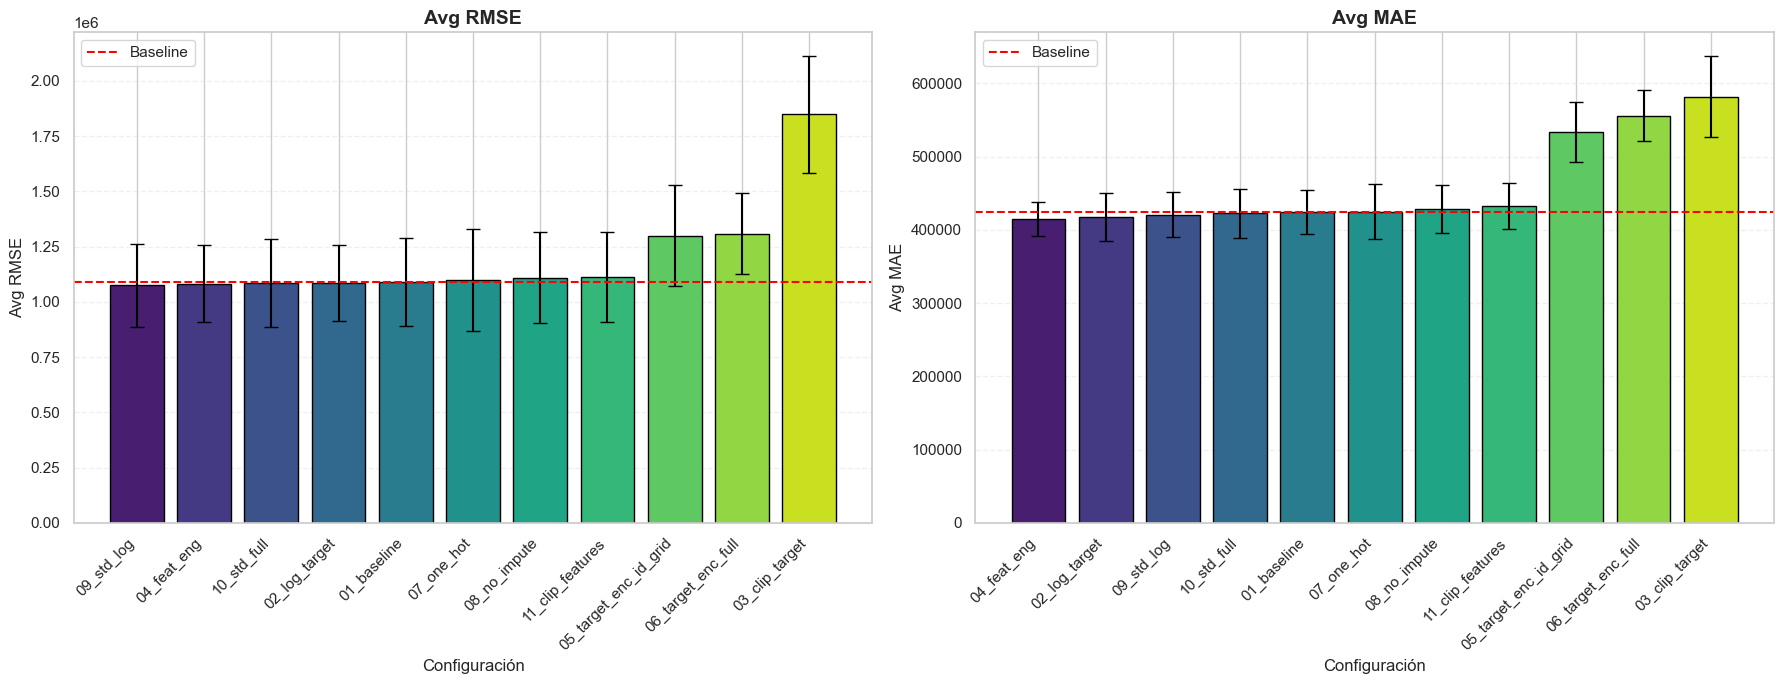

In [8]:
plot_cv_results(xgb_results_outliers, baseline_name="01_baseline", vertical_layout=False)

La primera observación en estos datasets es que los errores son muchísimos más altos. Esto es esperable: Un error promedio de 400.000 no es tan grave en un dataset cuya mediana es 3.000.000

Algo interesante es que la transformación logarítmica en este caso parece ayudar, contrario al dataset normal en el que no funcionó bien.

In [9]:
xgb_results_outliers_final = evaluate_pipeline_configs(
    model_factory=lambda fp: get_base_xgboost(fp),
    pipeline_configs=get_xgboost_final_configs(),
    X=X_outliers,
    y=y_outliers,
)

Evaluando Configuraciones: 100%|██████████| 4/4 [00:01<00:00,  2.15it/s]


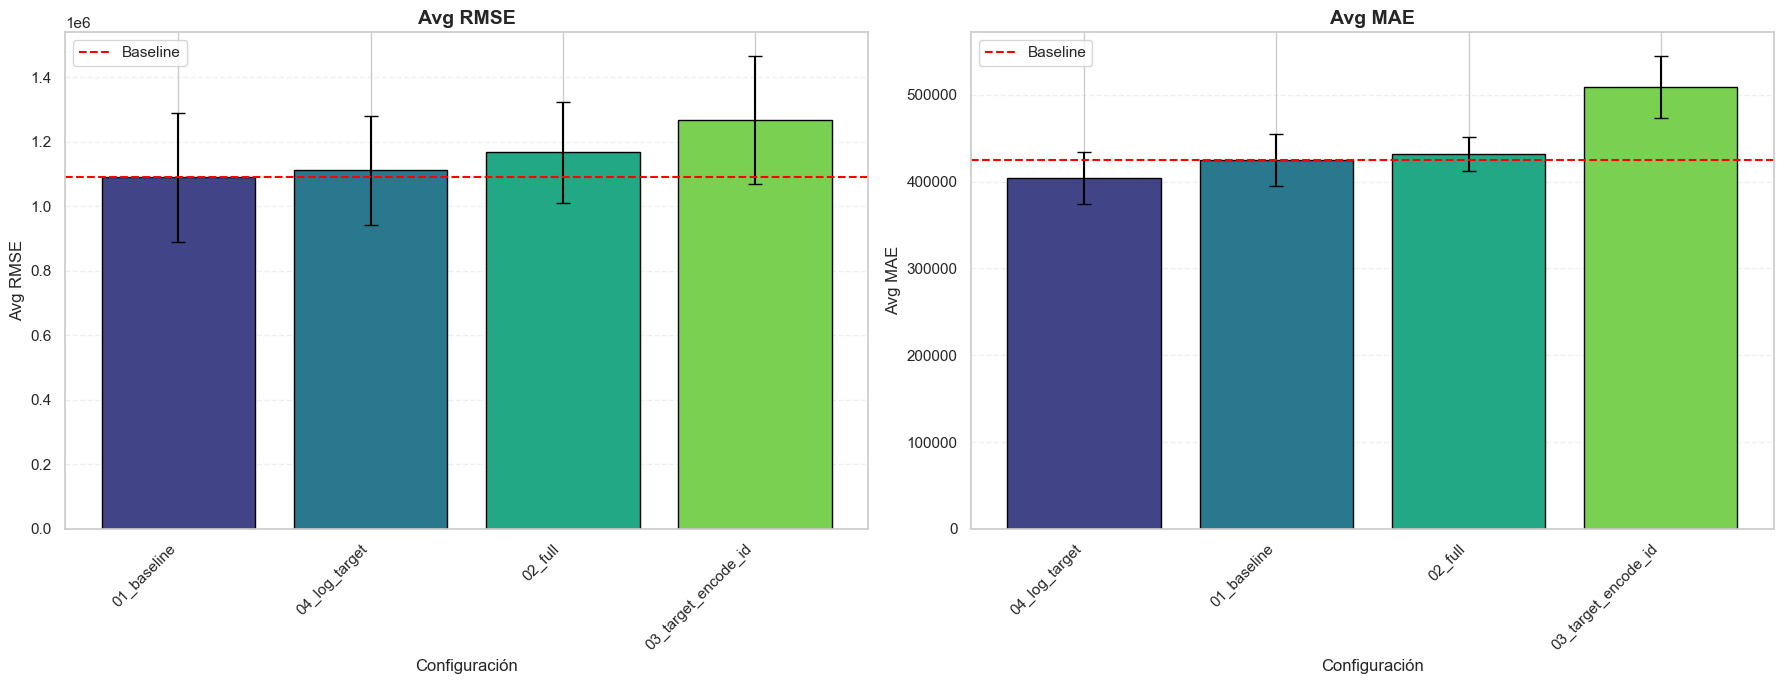

In [10]:
plot_cv_results(xgb_results_outliers_final, baseline_name="01_baseline", vertical_layout=False)

Efectivamente aplicar logaritmo al target ayuda levemente, particularmente al MAE. Esto nos da una idea:
- Para el dataset normal, vamos a usar la configuración `02_full`, que no aplica logaritmo al target
- Para el dataset de outliers, usamos `04_log_target`, que ayuda un poco a mejorar la performance del modelo

## 2. Modelos lineales

A diferencia de XGBoost, no podemos probar el impacto de cada transformación porque explota si no estandarizamos.

### 2.1 Dataset Normal
Obs: descartamos 05_log_target_scaled y 06_clip_log_target porque la performance es demasiado mala.

In [11]:
from sklearn.pipeline import Pipeline

ridge_configs = get_ridge_configs()
ridge_configs.pop("05_log_target_scaled")
ridge_configs.pop("06_clip_log_target")

ridge_results = evaluate_pipeline_configs(
    model_factory=lambda fp: Pipeline([
        ("features", fp),
        ("model", Ridge(alpha=100))
    ]),
    pipeline_configs=ridge_configs,
    X=X_normal,
    y=y_normal
)

Evaluando Configuraciones: 100%|██████████| 4/4 [00:10<00:00,  2.56s/it]


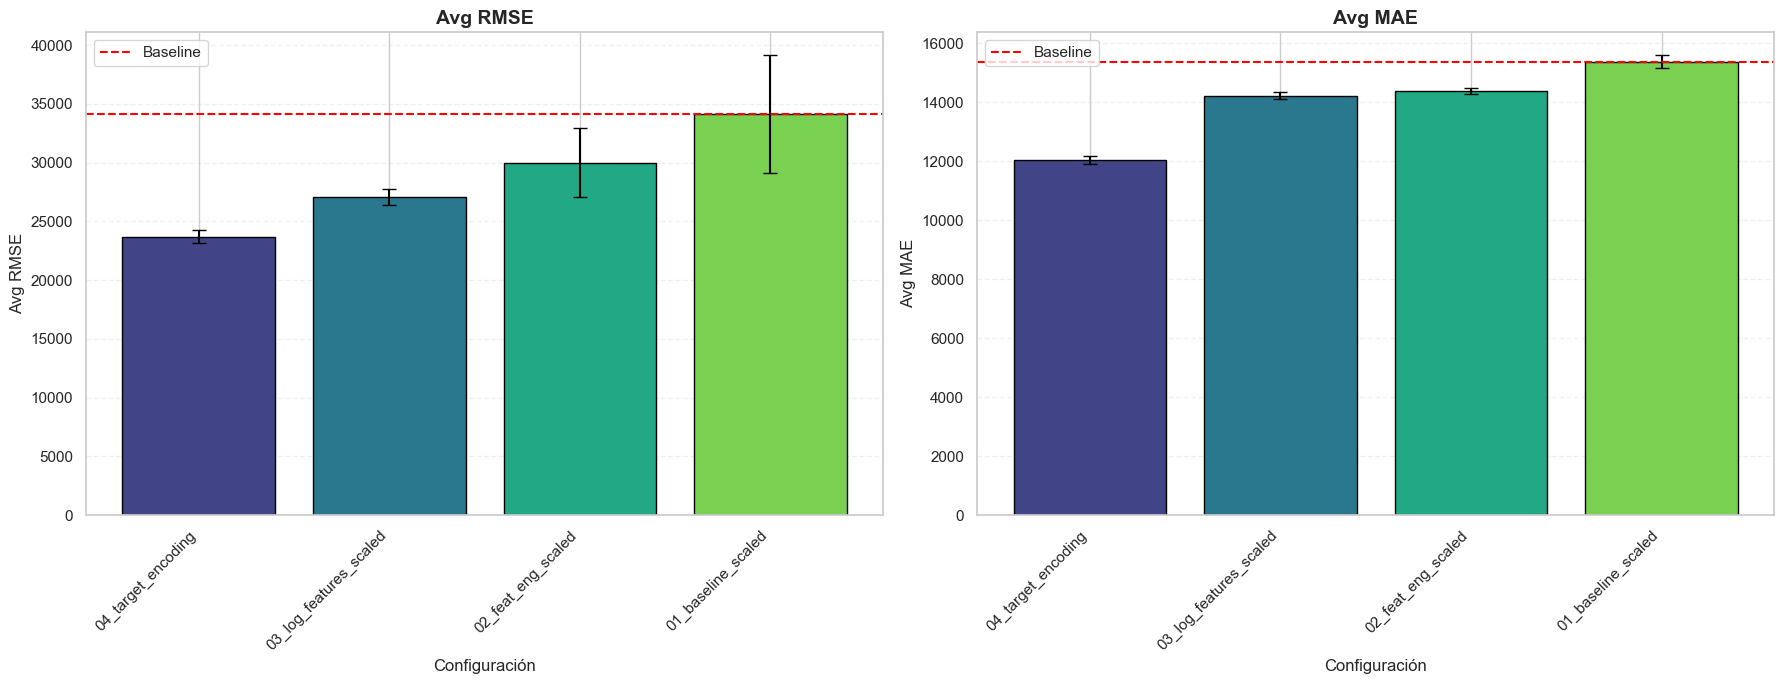

In [13]:
plot_cv_results(ridge_results, baseline_name="01_baseline_scaled", vertical_layout=False)

La configuración 04_target_encoding es claramente la ganadora. Interesantemente, aplicar logaritmo en el precio tuvo resultados extremadamente malos

### 2.2 Dataset Outliers

In [14]:
ridge_configs_outliers = get_ridge_configs()
ridge_configs_outliers.pop("02_feat_eng_scaled")
ridge_configs_outliers.pop("03_log_features_scaled")

ridge_results_outliers = evaluate_pipeline_configs(
    model_factory=lambda fp: Pipeline([
        ("features", fp),
        ("model", Ridge(alpha=100))
    ]),
    pipeline_configs=ridge_configs_outliers,
    X=X_outliers,
    y=y_outliers
)

Evaluando Configuraciones: 100%|██████████| 4/4 [00:00<00:00, 14.21it/s]


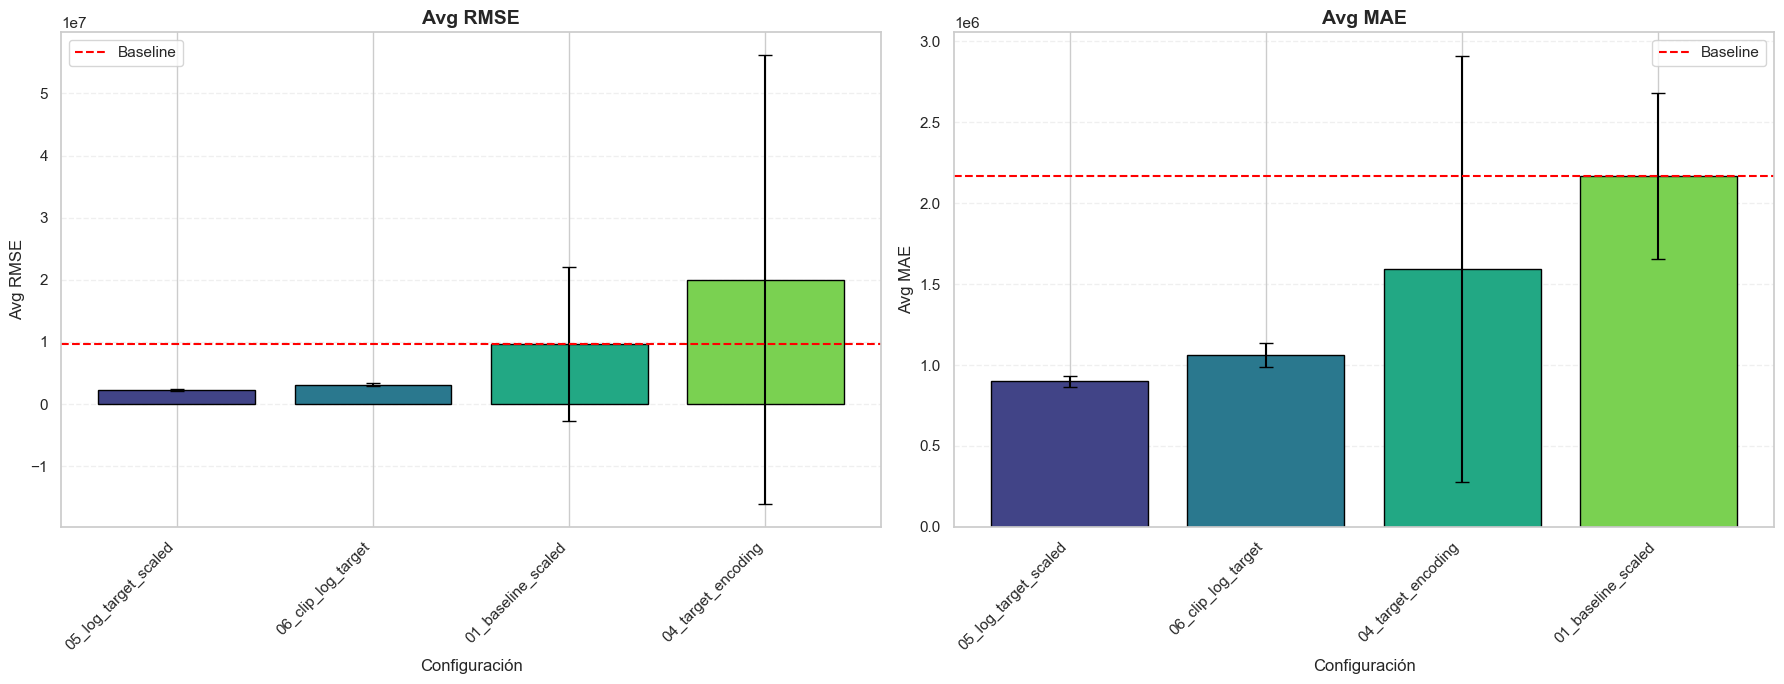

In [15]:
plot_cv_results(ridge_results_outliers, baseline_name="01_baseline_scaled", vertical_layout=False)

En este caso, a diferencia del dataset normal, aplicar logaritmo en el precio tuvo resultados muy buenos. 05_log_target_scaled es la clara ganadora.

# Conclusiones del Análisis de Preprocessing
## Dataset Normal (98.5% del mercado)
### **XGBoost - Ganadora: `02_full`**
- Feature engineering completo (amenities_score, densidad habitaciones, ratios, etc.)
- Imputación (mediana/moda) + Encoding (one-hot/ordinal)
- **SIN log ni scaling**: XGBoost no los requiere
-
**Hallazgo**: Los árboles solo necesitan buen feature engineering. Transformaciones adicionales no aportan.
### **Regresión Lineal - Ganadora: `04_target_encoding`**
- Mismo feature engineering que XGBoost
- **LOG en features sesgadas** (SUP_CONSTR, ANTIGUEDAD) para normalizar distribuciones
- **SCALING completo** (StandardScaler - obligatorio para modelos lineales)
- **Target Encoding** para alta cardinalidad (ID_GRID, BARRIO, CIUDAD)
**Hallazgo**: Modelos lineales requieren preprocesamiento intensivo (scaling + normalización).
---
## Dataset con Outliers (original completo)
### **XGBoost - Ganadora: `04_log_target`**
- Igual que `02_full` + **log transform del target**
- Mejora MAE (+40%) pero empeora RMSE en outliers extremos
### **Regresión Lineal - Ganadora: `05_log_target_scaled`**
- Igual que `04_target_encoding` + **log transform del target**
- Mismos trade-offs que XGBoost
---
## Implicancia para Deep Learning
**Usaremos la configuración de Regresión Lineal para entrenar redes neuronales**, ya que comparten requisitos:
- Features escaladas (convergencia del gradiente)
- Log transform en distribuciones sesgadas
- Target encoding para alta cardinalidad (facilita aprendizaje de embeddings)